# Training the model for Prediction
In this notebook, we will explain how to train your model with the objective of capturing antigen specificity, which usually leads to nicely balanced embeddings between TCR and Gene Expression. For this, we optimize the network hyperparameters to capture specificity in the embedding. Specifically, the weighted F1-Score for predicting pMHC specificity via a kNN classifier is evaluated between the training (atlas) and validation (query) set. In this set-up, it is necessary that cell-level pMHC specificity information is available.

In [16]:
# comet-ml must be imported before torch and sklearn
import comet_ml
import scanpy as sc

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Preperation
First we load the data via the Scanpy API. This data is derived from the 10x Application note "A new way of exploring immunity". Please follow the notebook "preprocessing/10x_preprocessing.ipynb" (https://github.com/SchubertLab/mvTCR_reproducibility/tree/master/preprocessing) to derive this dataset. We will use the second donor downsampled to 3000 cells and only cells that have a binder with a sufficient amount of counts.

In [17]:
adata = sc.read_h5ad('p1_preprocessed.h5ad')
adata

AnnData object with n_obs × n_vars = 51403 × 5000
    obs: 'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'has_binding', 'set'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'aa_to_id', 'chain_indices', 'clonotype', 'hvg', 'ir_dist_nt_identity', 'log1p', 'mouse_id_colors', 'mouse_id_enc'
    obsm: 'airr', 'alpha_seq', 'beta_seq', 'chain_indices', 'mouse_id_ohe'

Then we divide the data into training and validation data. Typically, a split of 20% validation data was used. The data is splitted to uniquely group 'clonotype' to either training or validation set.

## Defining the model parameters
We need to proivde the model a couple of parameters:
- study_name: Name for logging
- comet_workspace: we logged some of the experiments via Comet-ML. This gives you more information on the training process, but is not needed. We will therefore use None here. Otherwise, specifiy the workspace name of your Comet-ML project.
- model_name: assigns which model is used from (rna, tcr, moe, poe, concat). We will use the best performing moe.
- balanced_sample: oversample rare elements of this column. Recommended to use a column storing the clonotype to avoid overfitting.
- metadata: annotation to color the umaps when storing immediate results on Comet-ML. If no Comet-ML is used, pass an empty list
- save_path: path to store the trained models over multiple training runs
- n_epoch: amounts of epochs to train the model. For the paper we used 200 epochs. For showcasing however, we will reduce it to 5.

In [ ]:
params_experiment = {
    'study_name': '10x_prediction',
    'comet_workspace': None, 
    'model_name': 'moe',
    'balanced_sampling': 'clonotype',
    'metadata': [],
    'save_path': '../saved_models/Lee_EAE/epoch50',
    'n_epochs':50,
}

## Defining Optimization parameters
For this dataset, we will optimize to predict properties (TCR specificity, in this case) via knn-Atlas-Query-Matching within the dataset. This usually leads to nicely balanced embeddings between TCR and GEX. However, it requieres the annotation of TCR specificity in the column <prediction_column>.

In [19]:
params_optimization = {
    'name': 'knn_prediction',
    'prediction_column': 'tissue',
}

## Calling the training functions
Finally, we need to specificy a couple of parameters for running the training. Training will be aborted either after \<timeout\> seconds or after having trained 3 models with 1 available GPU.

In [20]:
from mvtcr.models.model_selection import run_model_selection

timeout = (20*60)
n_samples = 1
n_gpus = 1
seed = 42
run_model_selection(adata, params_experiment, params_optimization, n_samples, timeout, n_gpus, sampler_seed=seed)

[I 2025-09-08 22:24:51,067] A new study created in RDB with name: 10x_prediction


100%|██████████| 50/50 [35:51<00:00, 43.03s/it]
[I 2025-09-08 23:00:46,008] Trial 0 finished with value: 0.9995126712275847 and parameters: {'dropout': 0.1, 'activation': 'linear', 'rna_hidden': 1500, 'hdim': 200, 'shared_hidden': 100, 'rna_num_layers': 1, 'tfmr_encoding_layers': 4, 'loss_weights_kl': 4.0428727350273357e-07, 'loss_weights_tcr': 0.034702669886504146, 'lr': 1.0994335574766187e-05, 'zdim': 50, 'tfmr_embedding_size': 16, 'tfmr_num_heads': 8, 'tfmr_dropout': 0.15000000000000002}. Best is trial 0 with value: 0.9995126712275847.


Study statistics:
  Number of finished trials: 1
  Number of pruned trials: 0
  Number of complete trials: 1
Best trial: 
  trial_0
  Value: 0.9995126712275847


### Optuna Dashboard
Optionally you can use Optuna Dashboard to get more insights of e.g. how certain hyperparameters influence model selection. Find more information on how to use it here: https://optuna-dashboard.readthedocs.io/en/latest/getting-started.html

## Output
The console output indicates the best model after Hyperparameter Optimization. We will now load this model and embedd our data with it. Following, we can continue with standard analysis. Typically, we used considerable larger amount of training runs (e.g. 48 GPU-hours). Note: when increasing the number of GPUs, you will also need to scale the CPU resources, so that the training is not bottlenecked by e.g. dataloading on CPU.

In [24]:
import mvtcr.utils_training as utils
path_model = '../saved_models/LEE_EAE/epoch_50/' 
model = utils.load_model(adata, path_model+'best_model_by_metric.pt')

In [25]:
latent_moe = model.get_latent(adata, metadata=[], return_mean=True, copy_adata_obs=True)
latent_moe.write(path_model + 'latent_space.h5ad')
latent_moe

AnnData object with n_obs × n_vars = 51403 × 50
    obs: 'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'has_binding', 'set'

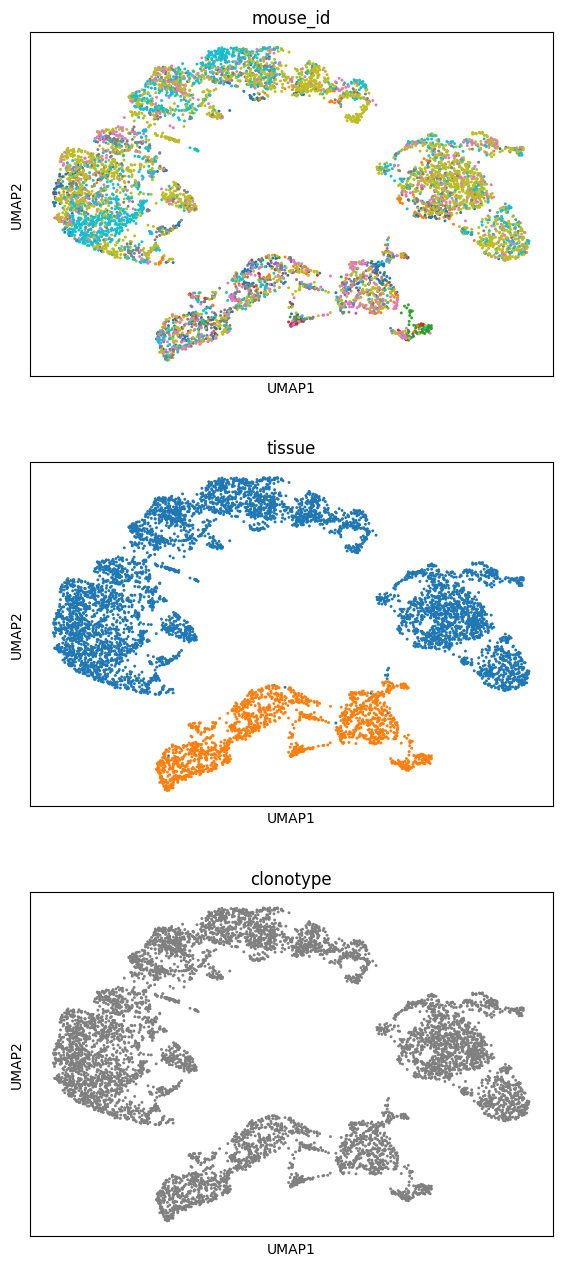

In [23]:
latent_sub = latent_moe[latent_moe.obs['clonotype_size'] > 2].copy()
sc.pp.neighbors(latent_sub, use_rep='X')
sc.tl.umap(latent_sub)

sc.pl.umap(latent_sub, color=['mouse_id', 'tissue', 'clonotype'], ncols=1, legend_loc=None)


Note, that the latent representation is highly separated to small clusters, that are mainly formed by one clonotype. This is due to the limited computational time (n_epochs, n_samples) spent to train these models in this tutorial.